## Import Libraries

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


## Load CIFAR-10 Dataset

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Training Images Shape:", x_train.shape)
print("Training Labels Shape:", y_train.shape)

print("Testing Images Shape:", x_test.shape)
print("Testing Labels Shape:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Training Images Shape: (50000, 32, 32, 3)
Training Labels Shape: (50000, 1)
Testing Images Shape: (10000, 32, 32, 3)
Testing Labels Shape: (10000, 1)


## Normalize Images

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

print("x_train normalized shape:", x_train.shape)
print("x_test normalized shape:", x_test.shape)
print("x_train min value:", x_train.min())
print("x_train max value:", x_train.max())

x_train normalized shape: (50000, 32, 32, 3)
x_test normalized shape: (10000, 32, 32, 3)
x_train min value: 0
x_train max value: 255


## Flatten Images for ANN

In [5]:
x_train_ann = x_train_norm.reshape(50000, 3072)
x_test_ann = x_test_norm.reshape(10000, 3072)

print(x_train_ann.shape)

(50000, 3072)


## Build Improved ANN Model
(increase Dense Layout)

In [6]:
ann_model = models.Sequential([

    layers.Dense(1024,
                 activation='relu',
                 input_shape=(3072,)),

    layers.Dropout(0.3),

    layers.Dense(512,
                 activation='relu'),

    layers.Dropout(0.3),

    layers.Dense(256,
                 activation='relu'),

    layers.Dropout(0.3),

    layers.Dense(128,
                 activation='relu'),

    layers.Dense(10,
                 activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


 ## Compile ANN

In [7]:
ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Early Stopping

In [8]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

## Train ANN
(20 epochs)

In [9]:
ann_history = ann_model.fit(
    x_train_ann,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 54s 71ms/step - accuracy: 0.2137 - loss: 2.0781 - val_accuracy: 0.2812 - val_loss: 1.9290
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 78s 66ms/step - accuracy: 0.2894 - loss: 1.9240 - val_accuracy: 0.3158 - val_loss: 1.8648
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 66ms/step - accuracy: 0.3102 - loss: 1.8744 - val_accuracy: 0.3462 - val_loss: 1.8208
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 68ms/step - accuracy: 0.3152 - loss: 1.8561 - val_accuracy: 0.3618 - val_loss: 1.7933
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step - accuracy: 0.3276 - loss: 1.8273 - val_accuracy: 0.3586 - val_loss: 1.7794
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 67ms/step - accuracy: 0.3379 - loss: 1.8062 - val_accuracy: 0.3424 - val_loss: 1.7895
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step - accuracy: 0.3400 - loss: 1.7987 - val_accuracy: 0.3738 - val_loss: 1.7458
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 67ms/step - accuracy: 0.3505 - loss: 1.7733 - 

## Evaluate ANN

In [10]:
ann_loss, ann_test_acc = ann_model.evaluate(
    x_test_ann,
    y_test
)

print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.4178 - loss: 1.6536
ANN Test Accuracy: 0.41780000925064087


## Build CNN Model

In [11]:
from tensorflow.keras import layers, models

cnn_model = models.Sequential([

    layers.Conv2D(
        32,
        (3,3),
        padding='same',
        activation='relu',
        input_shape=(32,32,3)
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        64,
        (3,3),
        padding='same',
        activation='relu'
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        128,
        (3,3),
        padding='same',
        activation='relu'
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(
        256,
        activation='relu'
    ),

    layers.Dropout(0.4),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dropout(0.3),

    layers.Dense(
        10,
        activation='softmax'
    )
])

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 652,874 (2.49 MB)

 Trainable params: 652,426 (2.49 MB)

 Non-trainable params: 448 (1.75 KB)

## compile cnn

In [12]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## early stopping

In [13]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

## train cnn

In [16]:
cnn_history = cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 200ms/step - accuracy: 0.9027 - loss: 0.2965 - val_accuracy: 0.7542 - val_loss: 0.8691
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 196ms/step - accuracy: 0.9059 - loss: 0.2809 - val_accuracy: 0.7692 - val_loss: 0.7740
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 139s 197ms/step - accuracy: 0.9136 - loss: 0.2607 - val_accuracy: 0.7632 - val_loss: 0.8736
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 139s 197ms/step - accuracy: 0.9178 - loss: 0.2528 - val_accuracy: 0.7648 - val_loss: 0.8890
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 139s 197ms/step - accuracy: 0.9213 - loss: 0.2384 - val_accuracy: 0.7588 - val_loss: 0.9088


## Evaluate CNN

In [17]:
cnn_loss, cnn_test_acc = cnn_model.evaluate(
    x_test_norm,
    y_test
)

print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.7472 - loss: 0.8777
CNN Test Accuracy: 0.7472000122070312


## Validation Accuracy Graph (ANN vs CNN)

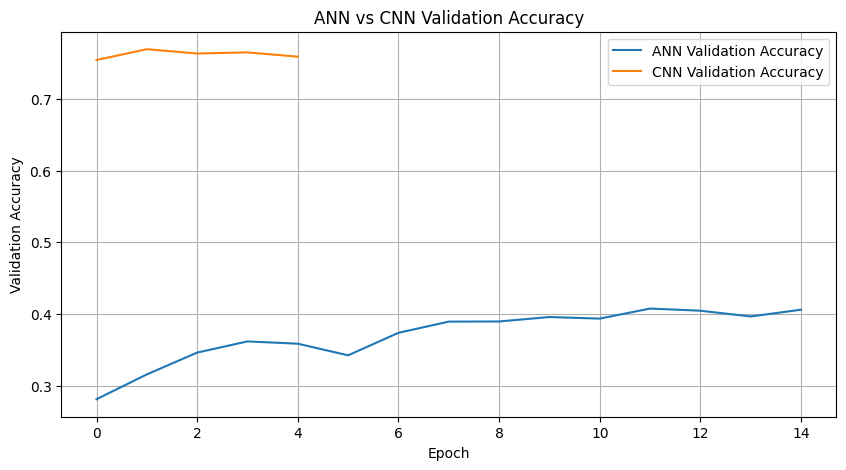

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    ann_history.history['val_accuracy'],
    label='ANN Validation Accuracy'
)

plt.plot(
    cnn_history.history['val_accuracy'],
    label='CNN Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

## Data Augmentation

In [19]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

## Build Augmented CNN

In [20]:
aug_cnn_model = models.Sequential([

    data_augmentation,

    layers.Conv2D(
        32,
        (3,3),
        padding='same',
        activation='relu',
        input_shape=(32,32,3)
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        64,
        (3,3),
        padding='same',
        activation='relu'
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        128,
        (3,3),
        padding='same',
        activation='relu'
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(
        256,
        activation='relu'
    ),

    layers.Dropout(0.4),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dropout(0.3),

    layers.Dense(
        10,
        activation='softmax'
    )
])

## Compile Augmented CNN

In [21]:
aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Train Augmented CNN

In [23]:
aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 152s 215ms/step - accuracy: 0.4724 - loss: 1.4776 - val_accuracy: 0.4940 - val_loss: 1.4166
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 150s 213ms/step - accuracy: 0.5335 - loss: 1.3199 - val_accuracy: 0.5844 - val_loss: 1.2122
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 204s 215ms/step - accuracy: 0.5692 - loss: 1.2284 - val_accuracy: 0.6024 - val_loss: 1.1826
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 148s 211ms/step - accuracy: 0.5959 - loss: 1.1565 - val_accuracy: 0.6298 - val_loss: 1.0600
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 203s 213ms/step - accuracy: 0.6201 - loss: 1.1003 - val_accuracy: 0.7012 - val_loss: 0.8983


## Evaluate Augmented CNN

In [24]:
aug_loss, aug_test_acc = aug_cnn_model.evaluate(
    x_test_norm,
    y_test
)

print("Augmented CNN Test Accuracy:", aug_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.4907 - loss: 1.4113
Augmented CNN Test Accuracy: 0.49070000648498535


In [27]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model":[
        "ANN",
        "CNN",
        "Augmented CNN"
    ],
    "Test Accuracy":[
        ann_test_acc,
        cnn_test_acc,
        aug_test_acc
    ]
})

print(comparison_df)

           Model  Test Accuracy
0            ANN         0.4178
1            CNN         0.7472
2  Augmented CNN         0.4907


In [28]:
best_model = comparison_df.loc[
    comparison_df['Test Accuracy'].idxmax()
]

print(best_model)

Model               CNN
Test Accuracy    0.7472
Name: 1, dtype: object
